#Import Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import GridSearchCV

In [32]:
import os
csv_files = [
    f for f in os.listdir('/content')
    if f.endswith('.csv')
]
print(csv_files)

['processed_house_price_data.csv', 'bengaluru_house_prices.csv', 'cleaned_house_data.csv']


#Load Datasets

In [33]:
df = pd.read_csv('bengaluru_house_prices.csv')

In [34]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


#Check missing values

In [35]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


#Fill Missing Values

In [36]:
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())
df['location'] = df['location'].fillna(df['location'].mode()[0])

In [37]:
df = df.drop('society', axis=1)

#Convert Area type into numbers

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['area_type'] = le.fit_transform(df['area_type'])

#saving cleaned dataset

In [39]:
df.to_csv("cleaned_house_data.csv", index=False)

#displaying the cleaned datasets

In [40]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,3,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,2,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,0,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,3,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,3,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


#Checking Dataset Shape and Column

In [41]:
df.shape

(13320, 8)

In [42]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  int64  
 1   availability  13320 non-null  object 
 2   location      13320 non-null  object 
 3   size          13304 non-null  object 
 4   total_sqft    13320 non-null  object 
 5   bath          13320 non-null  float64
 6   balcony       13320 non-null  float64
 7   price         13320 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 832.6+ KB


In [44]:
df[['availability','location','size','total_sqft']].head()

,availability,location,size,total_sqft
0,19-Dec,Electronic City Phase II,2 BHK,1056
1,Ready To Move,Chikka Tirupathi,4 Bedroom,2600
2,Ready To Move,Uttarahalli,3 BHK,1440
3,Ready To Move,Lingadheeranahalli,3 BHK,1521
4,Ready To Move,Kothanur,2 BHK,1200


#Removing the missing values

In [45]:
df.dropna(inplace=True)
df.shape

(13304, 8)

In [46]:
df['bhk'] = df['size'].apply(
    lambda x: int(x.split(' ')[0])
)

#Converting size into BHK

In [47]:
df[['size','bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


#Remove Original Size Column

In [48]:
df.drop('size', axis=1, inplace=True)

#Encoding categorical Columns

In [51]:
df = pd.get_dummies(
    df,
    columns=['availability','location'],
    drop_first=True
)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13065 entries, 0 to 13319
Columns: 1382 entries, area_type to location_whitefiled
dtypes: bool(1376), float64(4), int64(2)
memory usage: 17.8 MB


#Feature and Target

In [53]:
X = df.drop('price', axis=1)
y = df['price']

#Train-Test split

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(10452, 1381)
(2613, 1381)


#Baseline Model 1: Linear Regression

In [57]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
print("Linear Regression")
print("MAE:",
      mean_absolute_error(y_test, lr_pred))
print("MSE:",
      mean_squared_error(y_test, lr_pred))
print("R2:",
      r2_score(y_test, lr_pred))

Linear Regression
MAE: 40.39118324153708
MSE: 9414.299321573113
R2: 0.5235616250559324


#Baseline Model 2: Decision Tree

In [58]:
dt = DecisionTreeRegressor(
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree")
print("MAE:",
      mean_absolute_error(y_test, dt_pred))
print("MSE:",
      mean_squared_error(y_test, dt_pred))
print("R2:",
      r2_score(y_test, dt_pred))

Decision Tree
MAE: 35.841053360871385
MSE: 13359.743211954781
R2: 0.323890803961587


#Visualisation 1: Actual Vs Predicted

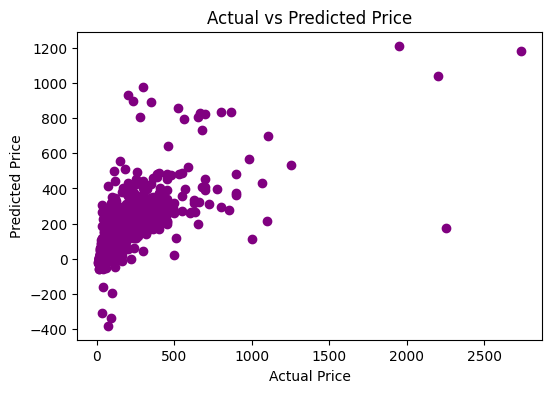

In [63]:
plt.figure(figsize=(6,4))
plt.scatter(
    y_test,
    lr_pred, color = 'purple'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.savefig("actual_vs_predicted.png")
plt.show()

#Visualisation 2: Residualplot

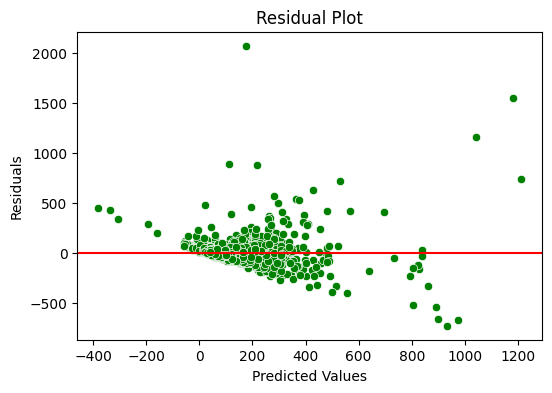

In [65]:
residuals = y_test - lr_pred
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=lr_pred,
    y=residuals, color = 'green'
)
plt.axhline(
    y=0,
    color='red'
)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("residual_plot.png")
plt.show()

#Hyperparameter tuning

In [66]:
param_grid = {
    'max_depth':[5,10,15,20],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

#Grid Search

In [75]:
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

#Best model

In [69]:
print(
    grid_search.best_params_
)

{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}


#Best model prediction

In [71]:
best_model = grid_search.best_estimator_
best_pred = best_model.predict(
    X_test
)

#Best Model Evaluation

In [72]:
print("Tuned Decision Tree")
print("MAE:",
      mean_absolute_error(y_test, best_pred))
print("MSE:",
      mean_squared_error(y_test, best_pred))
print("R2:",
      r2_score(y_test, best_pred))

Tuned Decision Tree
MAE: 38.14814698280278
MSE: 8870.07596374937
R2: 0.5511036527046582


#Model Comparison Graph

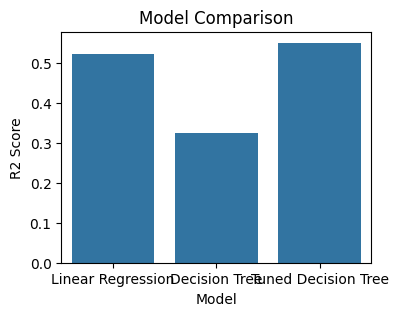

In [76]:
results = pd.DataFrame({
    'Model':['Linear Regression',
             'Decision Tree',
             'Tuned Decision Tree'],
    'R2 Score':[0.524,0.324,0.551]
})
plt.figure(figsize=(4,3))
sns.barplot(x='Model', y='R2 Score', data=results)
plt.title("Model Comparison")
plt.savefig("model_comparison.png")
plt.show()